# Random Forest modell

RF modell evaluert på testsett, ser hvor gode prediksjoner vi kan få. 

## Databehandling og trening av Random Forest

In [27]:
from snowflake.snowpark import Session
from snowflake.snowpark.context import get_active_session
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

def get_or_create_session(schema: str = None) -> Session:
    """Henter aktiv Snowpark-session eller oppretter lokal session ved behov."""
    if "POSIT_PRODUCT" in os.environ:
        session = Session.builder.getOrCreate()
        session.sql("USE DATABASE PROD_FOR_SKADE_PRODUKT_ADHOC").collect()
        if schema:
            session.sql("USE SCHEMA " + schema).collect()
        else:
            session.sql("USE SCHEMA PRODUKT_WRITE_DEV").collect()
        session.sql("USE WAREHOUSE SKADE_VWH").collect()
        return session

    try:
        return get_active_session()
    except Exception:
        import win32api

        if schema is None:
            schema = "PRODUKT_WRITE_DEV"

        connection_parameters = {
            "server": "km28161.west-europe.azure.snowflakecomputing.com",
            "warehouse": "SKADE_VWH",
            "account": "VK82539-KLP",
            "database": "PROD_FOR_SKADE_PRODUKT_ADHOC",
            "schema": schema,
            "user": win32api.GetUserNameEx(win32api.NameUserPrincipal),
            "authenticator": "externalbrowser",
        }
        return Session.builder.configs(connection_parameters).create()

session = get_or_create_session()
print("Session opprettet.")

Session opprettet.


In [28]:
# Les data (kjøres kun ved behov)
df_inngang = session.table("elh_write.inngangsdata").to_pandas()
df_inngang.columns = df_inngang.columns.str.lower()

df_info = session.table("inngangsdata_info").to_pandas()
df_info.columns = df_info.columns.str.lower()

df_weather = pd.read_csv("../../data/oslo_weather.csv", delimiter=";")
df_weather.columns = df_weather.columns.str.lower()

print(f"df_inngang: {df_inngang.shape}, df_info: {df_info.shape}, df_weather: {df_weather.shape}")

df_inngang: (157333, 14), df_info: (911, 108), df_weather: (731, 5)


In [29]:
# Databehandling og feature engineering
df_inngang["ankomst_dato"] = pd.to_datetime(
    df_inngang["ankomst_dato"], format="%d.%m.%Y %H:%M:%S"
 ).dt.date

df_inngang["behandlingstid"] = (
    df_inngang["behandlingstid"].str.split(":").apply(lambda x: int(x[0]) * 60 + int(x[1]))
)
df_inngang["etterbehandlingstid"] = (
    df_inngang["etterbehandlingstid"].str.split(":").apply(lambda x: int(x[0]) * 60 + int(x[1]))
)
df_inngang["behandlet"] = df_inngang["behandlet"].eq("Behandlet")

df_dag = (
    df_inngang.groupby("ankomst_dato", as_index=False)
    .agg(
        antall_samtaler=("unique_id", "size"),
        behandlet_andel=("behandlet", "mean"),
        tid_i_ko_snitt=("tid_i_ko", "mean"),
        behandlingstid_snitt=("behandlingstid", "mean"),
        total_behandlingstid=("behandlingstid", "sum"),
        etterbehandligstid_snitt=("etterbehandlingstid", "mean"),
        total_etterbehandligstid=("etterbehandlingstid", "sum"),
    )
    .sort_values("ankomst_dato")
    .reset_index(drop=True)
)

df_info["hf_dato"] = pd.to_datetime(df_info["hf_dato"], format="%Y-%m-%d").dt.date

df_weather["tid(norsk normaltid)"] = pd.to_datetime(
    df_weather["tid(norsk normaltid)"], format="%d.%m.%Y"
 ).dt.date
df_weather["nedbør (døgn)"] = (
    df_weather["nedbør (døgn)"].str.replace(",", ".", regex=True).astype(float)
)
df_weather["middeltemperatur (døgn)"] = (
    df_weather["middeltemperatur (døgn)"].str.replace(",", ".", regex=True).astype(float)
)
df_weather = df_weather.rename(
    columns={"nedbør (døgn)": "nedbør", "middeltemperatur (døgn)": "middeltemperatur"}
 )

df_temp = pd.merge(df_dag, df_info, left_on="ankomst_dato", right_on="hf_dato", how="left")
df = pd.merge(df_temp, df_weather, left_on="ankomst_dato", right_on="tid(norsk normaltid)", how="left")

month_key = pd.to_datetime(df["ankomst_dato"]).dt.to_period("M")
df["middeltemp_mndsnitt"] = df.groupby(month_key)["middeltemperatur"].transform("mean")
df["tempavvik_fra_mndsnitt"] = df["middeltemperatur"] - df["middeltemp_mndsnitt"]

df["antall_nye_kunder_b30_ny"] = (
    df["antall_nye_kunder_b30_mpb01_ny"]
    + df["antall_nye_kunder_b30_eph01_ny"]
    + df["antall_nye_kunder_b30_epf01_ny"]
    + df["antall_nye_kunder_b30_upr01_ny"]
)
df["antall_nye_kunder_b30_for"] = (
    df["antall_nye_kunder_b30_mpb01_for"]
    + df["antall_nye_kunder_b30_eph01_for"]
    + df["antall_nye_kunder_b30_epf01_for"]
    + df["antall_nye_kunder_b30_upr01_for"]
)
df["antall_hf_b30_ny"] = (
    df["antall_hf_b30_mpb01_ny"]
    + df["antall_hf_b30_eph01_ny"]
    + df["antall_hf_b30_epf01_ny"]
    + df["antall_hf_b30_upr01_ny"]
)
df["antall_hf_b30_for"] = (
    df["antall_hf_b30_mpb01_for"]
    + df["antall_hf_b30_eph01_for"]
    + df["antall_hf_b30_epf01_for"]
    + df["antall_hf_b30_upr01_for"]
)
df["stddev_premieendring_b30_for"] = (
    df["stddev_premieendring_b30_eph01_for"]
    + df["stddev_premieendring_b30_epf01_for"]
    + df["stddev_premieendring_b30_mpb01_for"]
    + df["stddev_premieendring_b30_upr01_for"]
) / 4
df["snitt_premieendring_b30_for"] = (
    df["snitt_premieendring_b30_eph01_for"]
    + df["snitt_premieendring_b30_epf01_for"]
    + df["snitt_premieendring_b30_mpb01_for"]
    + df["snitt_premieendring_b30_upr01_for"]
) / 4
df["antall_nye_kunder_b30_tot"] = df["antall_nye_kunder_b30_ny"] + df["antall_nye_kunder_b30_for"]
df["antall_hf_b30_tot"] = df["antall_hf_b30_ny"] + df["antall_hf_b30_for"]

cols_to_remove = [
    "hf_dato", "navn", "stasjon", "tid(norsk normaltid)", "ankomst_dato",
    "antall_nye_kunder_b7_mpb01_ny", "antall_nye_kunder_f30_mpb01_ny", "antall_nye_kunder_f7_mpb01_ny",
    "antall_hf_b7_mpb01_ny", "antall_hf_f30_mpb01_ny", "antall_hf_f7_mpb01_ny",
    "antall_nye_kunder_b7_eph01_for", "antall_nye_kunder_f30_eph01_for", "antall_nye_kunder_f7_eph01_for",
    "antall_hf_b7_eph01_for", "stddev_premieendring_b7_eph01_for", "snitt_premieendring_b7_eph01_for",
    "antall_hf_f30_eph01_for", "stddev_premieendring_f30_eph01_for", "snitt_premieendring_f30_eph01_for",
    "antall_hf_f7_eph01_for", "stddev_premieendring_f7_eph01_for", "snitt_premieendring_f7_eph01_for",
    "antall_nye_kunder_b7_eph01_ny", "antall_nye_kunder_f30_eph01_ny", "antall_nye_kunder_f7_eph01_ny",
    "antall_hf_b7_eph01_ny", "antall_hf_f30_eph01_ny", "antall_hf_f7_eph01_ny",
    "antall_nye_kunder_b7_epf01_ny", "antall_nye_kunder_f30_epf01_ny", "antall_nye_kunder_f7_epf01_ny",
    "antall_hf_b7_epf01_ny", "antall_hf_f30_epf01_ny", "antall_hf_f7_epf01_ny",
    "antall_nye_kunder_b7_epf01_for", "antall_nye_kunder_f30_epf01_for", "antall_nye_kunder_f7_epf01_for",
    "antall_hf_b7_epf01_for", "stddev_premieendring_b7_epf01_for", "snitt_premieendring_b7_epf01_for",
    "antall_hf_f30_epf01_for", "stddev_premieendring_f30_epf01_for", "snitt_premieendring_f30_epf01_for",
    "antall_hf_f7_epf01_for", "stddev_premieendring_f7_epf01_for", "snitt_premieendring_f7_epf01_for",
    "antall_nye_kunder_b7_upr01_ny", "antall_nye_kunder_f30_upr01_ny", "antall_nye_kunder_f7_upr01_ny",
    "antall_hf_b7_upr01_ny", "antall_hf_f30_upr01_ny", "antall_hf_f7_upr01_ny",
    "antall_nye_kunder_b7_mpb01_for", "antall_nye_kunder_f30_mpb01_for", "antall_nye_kunder_f7_mpb01_for",
    "antall_hf_b7_mpb01_for", "stddev_premieendring_b7_mpb01_for", "snitt_premieendring_b7_mpb01_for",
    "antall_hf_f30_mpb01_for", "stddev_premieendring_f30_mpb01_for", "snitt_premieendring_f30_mpb01_for",
    "antall_hf_f7_mpb01_for", "stddev_premieendring_f7_mpb01_for", "snitt_premieendring_f7_mpb01_for",
    "antall_nye_kunder_b7_upr01_for", "antall_nye_kunder_f30_upr01_for", "antall_nye_kunder_f7_upr01_for",
    "antall_hf_b7_upr01_for", "stddev_premieendring_b7_upr01_for", "snitt_premieendring_b7_upr01_for",
    "antall_hf_f30_upr01_for", "stddev_premieendring_f30_upr01_for", "snitt_premieendring_f30_upr01_for",
    "antall_hf_f7_upr01_for", "stddev_premieendring_f7_upr01_for", "snitt_premieendring_f7_upr01_for",
]
df = df.drop(columns=cols_to_remove, errors="ignore")

print(f"Ferdig prosessert modell-data: {df.shape}")

Ferdig prosessert modell-data: (500, 54)


In [30]:
# Definer kovariater eksplisitt (samme oppsett som i de andre notebookene)
covs = [
    "kvartal", "maaned", "ukenummer", "ukedag", "dag_i_maaned",
    "er_helg", "helligdag", "er_helligdag", "er_dag_foer_helligdag", "er_dag_etter_helligdag",
    "middeltemperatur", "tempavvik_fra_mndsnitt", "nedbør",
    "antall_nye_kunder_b30_ny", "antall_nye_kunder_b30_for",
    "antall_hf_b30_ny", "antall_hf_b30_for",
    "stddev_premieendring_b30_for", "snitt_premieendring_b30_for",
    "antall_nye_kunder_b30_tot", "antall_hf_b30_tot",
]

print(f"Antall kovariater definert: {len(covs)}")

Antall kovariater definert: 21


In [31]:
# Splitt data (random) og tren modell
target = "antall_samtaler"
covs = [c for c in covs if c in df.columns and c != target]

model_df = df[[target] + covs].copy()
model_df = model_df.dropna(subset=[target]).reset_index(drop=True)
X = model_df[covs]
y = model_df[target]

categorical_features = [
    c
    for c in [
        "kvartal", "maaned", "ukenummer", "ukedag", "dag_i_maaned",
        "er_helg", "helligdag", "er_helligdag", "er_dag_foer_helligdag", "er_dag_etter_helligdag",
    ]
    if c in X.columns
]
numeric_features = [c for c in X.columns if c not in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
 )

model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", rf_model),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Kovariater brukt: {len(covs)}")
print(f"Antall rader totalt: {len(model_df)}")
print(f"Train-storrelse: {len(X_train)}, Test-storrelse: {len(X_test)}")

Kovariater brukt: 21
Antall rader totalt: 500
Train-storrelse: 400, Test-storrelse: 100


In [32]:
# Evaluering på testsett
from sklearn.metrics import mean_absolute_error, r2_score, mean_poisson_deviance

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

# Poisson deviance krever positive prediksjoner
eps = 1e-9
y_pred_pos = np.clip(y_pred, eps, None)
poisson_dev_test = mean_poisson_deviance(y_test, y_pred_pos)

# Nullmodell (predikerer treningssnittet)
y_null = np.full_like(y_test.to_numpy(dtype=float), fill_value=float(y_train.mean()), dtype=float)
y_null_pos = np.clip(y_null, eps, None)

mse_null = mean_squared_error(y_test, y_null)
mae_null = mean_absolute_error(y_test, y_null)
poisson_dev_null = mean_poisson_deviance(y_test, y_null_pos)

# Skill score: >0 er bedre enn nullmodell, 1 er perfekt
mse_skill = 1 - (mse_test / mse_null)
poisson_skill = 1 - (poisson_dev_test / poisson_dev_null)

print(f"MSE (test): {mse_test:.4f}")
print(f"RMSE (test): {rmse_test:.4f}")
print(f"MAE (test): {mae_test:.4f}")
print(f"R2 (test): {r2_test:.4f}")
print(f"Poisson deviance (test): {poisson_dev_test:.4f}")

print("\nNullmodell (test):")
print(f"MSE null: {mse_null:.4f}")
print(f"MAE null: {mae_null:.4f}")
print(f"Poisson deviance null: {poisson_dev_null:.4f}")

print("\nSkill vs nullmodell:")
print(f"MSE skill: {mse_skill:.4f}")
print(f"Poisson skill: {poisson_skill:.4f}")

MSE (test): 6409.4375
RMSE (test): 80.0590
MAE (test): 62.1484
R2 (test): 0.3191
Poisson deviance (test): 22.6812

Nullmodell (test):
MSE null: 10212.2627
MAE null: 81.9054
Poisson deviance null: 36.1692

Skill vs nullmodell:
MSE skill: 0.3724
Poisson skill: 0.3729


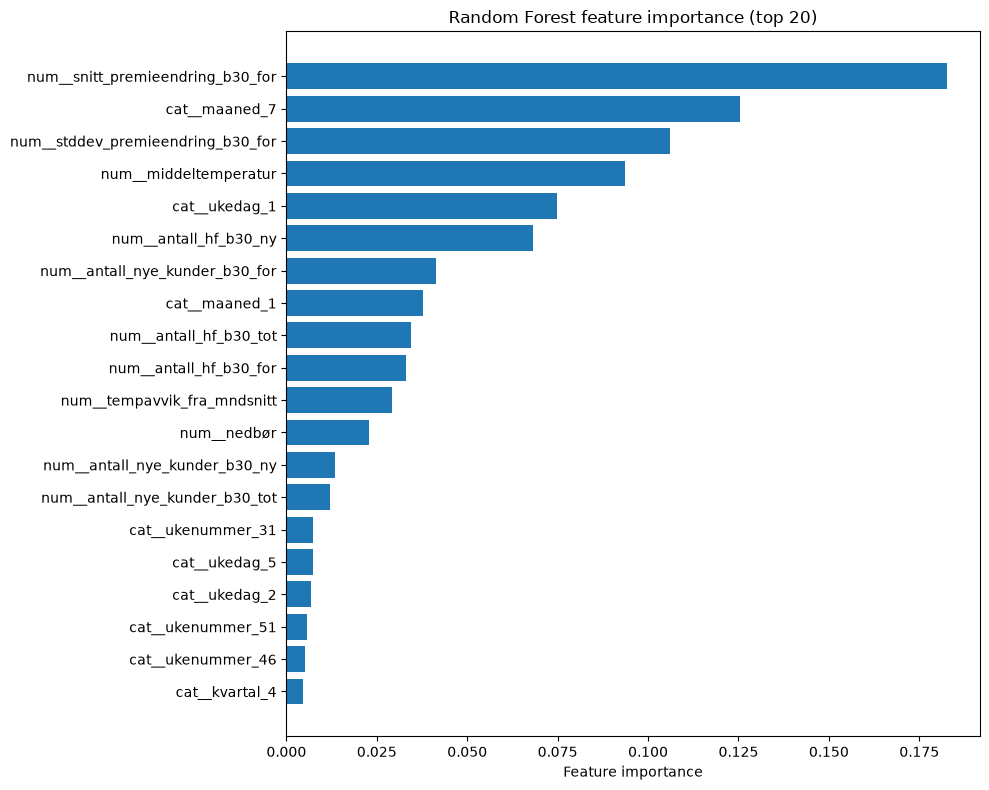

,feature,importance
8,num__snitt_premieendring_b30_for,0.182642
21,cat__maaned_7,0.125448
7,num__stddev_premieendring_b30_for,0.105966
0,num__middeltemperatur,0.093511
80,cat__ukedag_1,0.074842
5,num__antall_hf_b30_ny,0.068206
4,num__antall_nye_kunder_b30_for,0.041380
15,cat__maaned_1,0.037814
10,num__antall_hf_b30_tot,0.034420
6,num__antall_hf_b30_for,0.033036


In [33]:
# Feature importance-plot
prep = model.named_steps["preprocessor"]
rf = model.named_steps["rf"]

feature_names = prep.get_feature_names_out()
importances = rf.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

top_n = 20
fi_top = fi.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Feature importance")
plt.title(f"Random Forest feature importance (top {top_n})")
plt.tight_layout()
plt.show()

display(fi.head(20))